In [12]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd

from matplotlib import rcParams
# Use Arial for all math text
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Helvetica"
plt.rcParams["mathtext.it"] = "Helvetica:italic"
plt.rcParams["mathtext.bf"] = "Helvetica:bold"

# Use Arial for all normal text
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

In [13]:
nat_blue   = (74/255, 111/255, 165/255)   # Mediterranean sky blue
res_red    = (200/255, 74/255, 61/255)    # Vermilion / poppy red
line_brown  = (139/255, 107/255, 79/255)   # Warm umber earth
line_green  = (111/255, 143/255, 94/255)   # Olive landscape green
line_purple = (106/255, 76/255, 125/255)   # Muted aubergine purple
all_lake_neutral = (28/255, 24/255, 20/255)
grey_background = (235/255, 233/255, 228/255)

In [14]:
# Load data
df_trend_correct = pd.read_csv("../../Processed_Data/Processed_Lake.txt", sep=",")
df_area = pd.read_csv("../../Processed_Data/Lake_maximum_storgae_change.txt", sep="\t")

# Split by lake type
all_lakes = df_trend_correct["Trend"].dropna().abs().values
res = df_trend_correct[df_trend_correct["TypeName"] == "Reservoir"]["Trend"].dropna().abs().values
nat = df_trend_correct[df_trend_correct["TypeName"] == "Natural lake"]["Trend"].dropna().abs().values

# Split by lake type
all_lakes_area = df_area["Area_km"].dropna().values
res_area = df_area[df_area["LakeType"] == "Reservoir"]["Area_km"].dropna().values
nat_area = df_area[df_area["LakeType"] == "NaturalLake"]["Area_km"].dropna().values

all_lakes_log10 = np.log10(all_lakes)
res_log10 = np.log10(res)
nat_log10 = np.log10(nat)

all_lakes_area_log10 = np.log10(all_lakes_area)
res_area_log10 = np.log10(res_area)
nat_area_log10 = np.log10(nat_area)

# Number of bins
bin_width = 0.2   # example: 1 in log10 space
bins = np.arange(-4,
                 2 + bin_width,
                 bin_width)


# Number of bins
bin_width_area = 0.2   # example: 1 in log10 space
bins_area = np.arange(-4,
                 4 + bin_width_area,
                 bin_width_area)


# Histogram counts
counts_all_lakes_area, bin_edges_all_lakes_area = np.histogram(all_lakes_area_log10, bins=bins_area)
counts_res_area, bin_edges_res_area = np.histogram(res_area_log10, bins=bins_area)
counts_nat_area, bin_edges_nat_area = np.histogram(nat_area_log10, bins=bins_area)

# Histogram counts
counts_all_lakes, bin_edges_all_lakes = np.histogram(all_lakes_log10, bins=bins)
counts_res, bin_edges_res = np.histogram(res_log10, bins=bins)
counts_nat, bin_edges_nat = np.histogram(nat_log10, bins=bins)

# Relative frequency per bin
rel_freq_all_lakes_area = counts_all_lakes_area / len(all_lakes_area_log10)
rel_freq_res_area = counts_res_area / len(res_area_log10)
rel_freq_nat_area = counts_nat_area / len(nat_area_log10)

# Relative frequency per bin
rel_freq_all_lakes = counts_all_lakes / len(all_lakes_log10)
rel_freq_res = counts_res / len(res_log10)
rel_freq_nat = counts_nat / len(nat_log10)

# Plot
w_all_lakes = np.ones_like(all_lakes_log10) / len(all_lakes_log10)
w_res = np.ones_like(res_log10) / len(res_log10)
w_nat = np.ones_like(nat_log10) / len(nat_log10)

# Plot
w_all_lakes_area = np.ones_like(all_lakes_area_log10) / len(all_lakes_area_log10)
w_res_area = np.ones_like(res_area_log10) / len(res_area_log10)
w_nat_area = np.ones_like(nat_area_log10) / len(nat_area_log10)

# plt.hist(all_lakes_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_all_lakes, edgecolor = all_lake_neutral)
# plt.hist(res_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_res, edgecolor = res_red)
# plt.hist(nat_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_nat, edgecolor = nat_blue)
# plt.ylabel("Relative frequency")

/var/folders/vv/gtlg3n515xx1w7zpydhzsrpm0000gn/T/ipykernel_1190/51181896.py:15: RuntimeWarning: divide by zero encountered in log10
  all_lakes_log10 = np.log10(all_lakes)
/var/folders/vv/gtlg3n515xx1w7zpydhzsrpm0000gn/T/ipykernel_1190/51181896.py:16: RuntimeWarning: divide by zero encountered in log10
  res_log10 = np.log10(res)
/var/folders/vv/gtlg3n515xx1w7zpydhzsrpm0000gn/T/ipykernel_1190/51181896.py:17: RuntimeWarning: divide by zero encountered in log10
  nat_log10 = np.log10(nat)


In [15]:
# Load data
df_lake_trends = pd.read_csv(
    "../../Processed_Data/WaterStorageTrend.txt",
    sep=r"\s+",        # whitespace-separated
    comment="#"
)

# Colors (converted from MATLAB RGB/255)
color_pos = (213/255, 118/255, 107/255)
color_neg = (168/255, 200/255, 228/255)

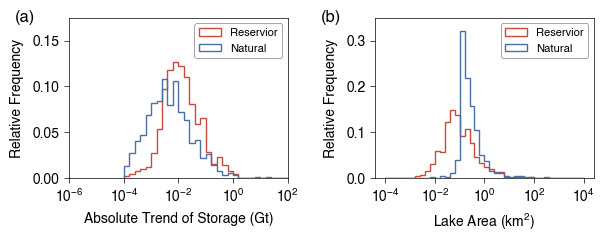

In [16]:
fig = plt.figure(figsize = (6.77, 8/3.5))

# 2 columns with exact width ratios: 3/5 and 2/5
gs = GridSpec(
    1, 2,
    figure=fig,
    # width_ratios=[1, 1],     # row 2 uses this (left bigger)
    # height_ratios=[1.61, 1, 1], # can adjust if needed
    # left=0.1, right=0.95,
    bottom=0.25, top=0.95,
    wspace=0.4,
    # hspace=0.9
)

# # --- Row 1 (full width) ---

# --- Row 3 (equal size) ---
ax3 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# -----------------------------
# lake area difference
# -----------------------------


ax2.hist(res_area_log10, bins=bins_area, histtype="step", linewidth=1, weights=w_res_area, edgecolor = res_red, label="Reservior")
ax2.hist(nat_area_log10, bins=bins_area, histtype="step", linewidth=1, weights=w_nat_area, edgecolor = nat_blue, label="Natural")
# ax2.hist(all_lakes_area_log10, bins=bins_area, histtype="step", linewidth=1, weights=w_all_lakes_area, edgecolor = all_lake_neutral, label="All")

ax2.set_xlabel("Lake Area (km$^{\mathrm{2}}$)", labelpad=5)
ax2.set_ylabel("Relative Frequency", labelpad=6)
ax2.set_ylim(0,0.35)
ax2.set_xticks(np.arange(-4,5,2))
ax2.set_xticklabels([r"$10^{-4}$", r"$10^{-2}$",  r"$10^{0}$", r"$10^{2}$", r"$10^{4}$"])
ax3.set_xlim(-4,2)

leg2 = ax2.legend(fontsize=8, loc = 'upper right')
# Control legend frame appearance
frame2 = leg2.get_frame()
frame2.set_alpha(1)       # transparency
frame2.set_linewidth(0.5)   # frame thickness
frame2.set_edgecolor("grey")

# -----------------------------
# peak to peak difference
# -----------------------------


ax3.hist(res_log10, bins=bins, histtype="step", linewidth=1, weights=w_res, edgecolor = res_red, label="Reservior")
ax3.hist(nat_log10, bins=bins, histtype="step", linewidth=1, weights=w_nat, edgecolor = nat_blue, label="Natural")
# ax3.hist(all_lakes_log10, bins=bins, histtype="step", linewidth=1, weights=w_all_lakes, edgecolor = all_lake_neutral, label="All")

ax3.set_xlabel("Absolute Trend of Storage (Gt)", labelpad=5)
ax3.set_ylabel("Relative Frequency", labelpad=6)
ax3.set_ylim(0,0.175)
ax3.set_xticks(np.arange(-6,3,2))
ax3.set_xticklabels([r"$10^{-6}$",  r"$10^{-4}$", r"$10^{-2}$",  r"$10^{0}$", r"$10^{2}$"])
# ax3.set_xlim(-3,3)

leg3 = ax3.legend(fontsize=8, loc = 'upper right')
# Control legend frame appearance
frame3 = leg3.get_frame()
frame3.set_alpha(1)       # transparency
frame3.set_linewidth(0.5)   # frame thickness
frame3.set_edgecolor("grey")

### Frame Style ###
for ax, label in [(ax2, '(b)'), (ax3, '(a)')]:
    ax.text(-0.25, 1.05, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

### Frame Style ###

for ax in [ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.tick_params(width=0.5)  # match tick thickness to frame

# Save for submission
plt.savefig("lake_stats.pdf", dpi=600)
plt.savefig("lake_stats.png", dpi=600)
plt.show()